# Package Usage Example Notebook

## 1. Compute Geometric features

import the class `GeometricFeatureCalculator`

In [ ]:
from point_cloud_classifier.data_handler import GeometricFeatureCalculator

create a new pointcloud with geometric features computed. The following code block runs withh all the per default set features `REQUIRED_FEATURES`, which are defined in `point_cloud_classifier.constants`. Its also possible to compute each feature type individually (3D-features, 2D-features, 1D-feature or Z-features)

In [ ]:
input_pointcloud_path = r".\Essais\inputRawPointCloud\2551000_1204000.copc.laz"
output_pointcloud_path = r".\Essais\OutputRawPointCloud\0_2551000_1204000.laz" # cannot write .copc output

data_handler = GeometricFeatureCalculator(input_pointcloud_path)
data_handler.compute_features() # compute all geometric features per default, the output is in the instance of the class and will be lost if not save to a file
data_handler.write_point_cloud(output_pointcloud_path) # -> saves the pointcloud in .laz format

if an entire directory of tiles needs to be computed, an iteration can be done

In [ ]:
import os

input_directory = r".\Essais\inputRawPointCloud"
output_directory = r".\Essais\outputRawPointCloud"
for file in os.listdir(input_directory):
    if not file.endswith('.laz') or not file.endswith('.las'):
        continue
    data_handler = GeometricFeatureCalculator(os.path.join(input_directory, file)) # will be overwritten at every new iteration to avoid too much memory allocation
    data_handler.compute_features()
    data_handler.write_point_cloud(os.path.join(output_directory, file))


## 2. Classify Point Cloud

In [3]:
import os
import importlib
if os.getcwd().endswith("docs"):
    os.chdir("../")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", force=True)

import point_cloud_classifier.classifier
importlib.reload(point_cloud_classifier.classifier)
from point_cloud_classifier.classifier import PointCloudClassifier, DataClassifierFormat
importlib.reload(point_cloud_classifier.helper)
from point_cloud_classifier.helper import visualize_point_cloud_classification

Loading dataset: 100%|██████████| 1/1 [00:18<00:00, 18.28s/pointcloud]


In [13]:
point_cloud_path = r"D:\Raphael\Essais\TestPointcloud\10_2553000_1216500_tile2.laz"
classifier = PointCloudClassifier()
# points, X = DataClassifierFormat.load_data(point_cloud_path)
points, X, Y = DataClassifierFormat.load_data(point_cloud_path, return_classification=True, fraction_of_dataset=1) # already classified point cloud to check the quality of the classifier

Loading dataset: 100%|██████████| 1/1 [00:13<00:00, 13.39s/pointcloud]


### 2.0 Classify all classes

In [27]:
all_labels = classifier.predict(X, points)
visualize_point_cloud_classification(points, all_labels, "./visualization/All_classified_campagne.laz") # creates a pointcloud as output where we caan visualize the classified pointcloud

Prediction over patches:   0%|          | 0/1 [00:00<?, ?patch/s]

Prediction over patches: 100%|██████████| 1/1 [00:53<00:00, 53.51s/patch]


### 2.1 Ground Classification

In [ ]:
ground_id = 2
ground_labels = classifier.classify_ground_points(X) # return 1 if its classified as ground and else 0
classifier.test_binary_classifier(ground_labels, Y==ground_id) # outputs the classifier metrics on the tested data
visualize_point_cloud_classification(points, ground_labels * ground_id, "./visualization/GroundClassified.laz") # creates a pointcloud as output where we caan visualize the classified pointcloud

2026-06-18 09:08:53,190 - INFO - ==================================================
2026-06-18 09:08:53,191 - INFO - Résultats Globaux :
2026-06-18 09:08:53,193 - INFO -  -> Accuracy  : 98.40 %
2026-06-18 09:08:53,194 - INFO -  -> F1-Score  : 0.9819
2026-06-18 09:08:53,195 - INFO -  -> Recall    : 0.9732
2026-06-18 09:08:53,197 - INFO -  -> Precision : 0.9907
2026-06-18 09:08:53,198 - INFO - ==================================================


Get the classifiers feature importance

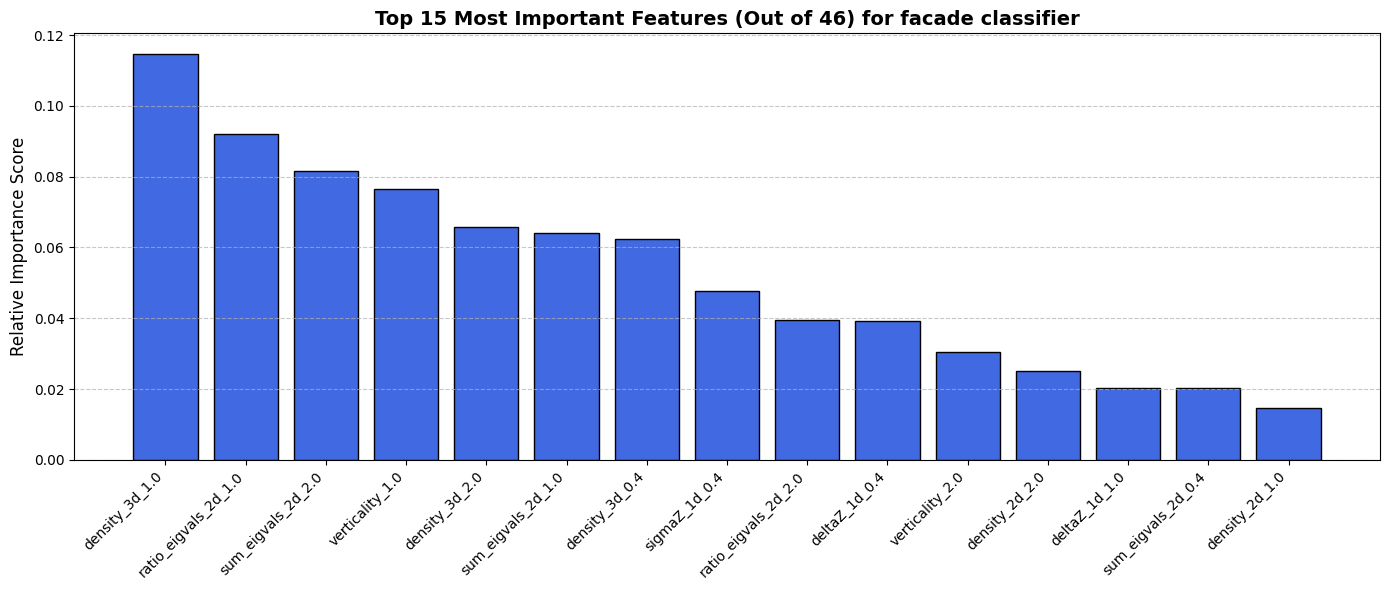

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from point_cloud_classifier.constants import SELECTED_FEATURE_NAMES

importances = classifier.binary_ground_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15
top_indices = indices[:top_n]

plt.figure(figsize=(14, 6))
plt.title(f"Top {top_n} Most Important Features (Out of 46) for ground classifier", fontsize=14, fontweight='bold')
plt.bar(range(top_n), importances[top_indices], color='royalblue', edgecolor='black', align="center")
plt.xticks(range(top_n), [SELECTED_FEATURE_NAMES[i] for i in top_indices], rotation=45, ha='right', fontsize=10)
plt.ylabel("Relative Importance Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 2.2 (Large) Vegetation Classification

In [ ]:
vegetation_id = 3
mask1 = ~ground_labels.astype(bool)
vegetation_labels = classifier.classify_vegetation_points(points[mask1], X[mask1])
classifier.test_binary_classifier(vegetation_labels, Y[mask1]==vegetation_id)
visualize_point_cloud_classification(points[mask1], vegetation_labels * vegetation_id, "./visualization/VegetationClassified.laz")

2026-06-18 09:09:09,064 - INFO - ==================================================
2026-06-18 09:09:09,065 - INFO - Résultats Globaux :
2026-06-18 09:09:09,066 - INFO -  -> Accuracy  : 96.30 %
2026-06-18 09:09:09,068 - INFO -  -> F1-Score  : 0.8289
2026-06-18 09:09:09,070 - INFO -  -> Recall    : 0.7090
2026-06-18 09:09:09,071 - INFO -  -> Precision : 0.9976
2026-06-18 09:09:09,072 - INFO - ==================================================


### 2.3 Roof Classification

In [ ]:
roof_id = 6
mask2 = ~vegetation_labels.astype(bool)
roof_labels = classifier.classify_roof_points(points[mask1][mask2], X[mask1][mask2])
classifier.test_binary_classifier(roof_labels, Y[mask1][mask2]==roof_id)
visualize_point_cloud_classification(points[mask1][mask2], roof_labels * roof_id, "./visualization/RoofClassified.laz")

2026-06-18 10:28:04,107 - INFO - ==================================================
2026-06-18 10:28:04,108 - INFO - Résultats Globaux :
2026-06-18 10:28:04,109 - INFO -  -> Accuracy  : 92.87 %
2026-06-18 10:28:04,110 - INFO -  -> F1-Score  : 0.9504
2026-06-18 10:28:04,111 - INFO -  -> Recall    : 0.9260
2026-06-18 10:28:04,113 - INFO -  -> Precision : 0.9761
2026-06-18 10:28:04,114 - INFO - ==================================================


### 2.4 Facade Classification

In [30]:
facade_id = 22
mask3 = ~roof_labels.astype(bool)
facade_labels = classifier.classify_facade_points(points[mask1][mask2][mask3], X[mask1][mask2][mask3], points[mask1][mask2][~mask3])
classifier.test_binary_classifier(facade_labels, Y[mask1][mask2][mask3]==facade_id)
visualize_point_cloud_classification(points[mask1][mask2][mask3], facade_labels * facade_id, "./visualization/FacadeClassified.laz")

2026-06-18 11:26:11,028 - INFO - ==================================================
2026-06-18 11:26:11,028 - INFO - Résultats Globaux :
2026-06-18 11:26:11,029 - INFO -  -> Accuracy  : 90.49 %
2026-06-18 11:26:11,030 - INFO -  -> F1-Score  : 0.9040
2026-06-18 11:26:11,031 - INFO -  -> Recall    : 0.9062
2026-06-18 11:26:11,031 - INFO -  -> Precision : 0.9018
2026-06-18 11:26:11,032 - INFO - ==================================================


### 2.5 Roof Structure Classification

In [33]:
roof_structure_id = 26
mask4 = ~facade_labels.astype(bool)
roof_structure_labels = classifier.classify_roof_structure_points(points[mask1][mask2][mask3][mask4], points[mask1][mask2][~mask3])
classifier.test_binary_classifier(roof_structure_labels, Y[mask1][mask2][mask3][mask4]==roof_structure_id)
visualize_point_cloud_classification(points[mask1][mask2][mask3][mask4], roof_structure_labels * roof_structure_id, "./visualization/RoofStructureClassified.laz")

2026-06-18 11:30:18,018 - INFO - ==================================================
2026-06-18 11:30:18,019 - INFO - Résultats Globaux :
2026-06-18 11:30:18,020 - INFO -  -> Accuracy  : 87.30 %
2026-06-18 11:30:18,022 - INFO -  -> F1-Score  : 0.5189
2026-06-18 11:30:18,022 - INFO -  -> Recall    : 0.9315
2026-06-18 11:30:18,022 - INFO -  -> Precision : 0.3596
2026-06-18 11:30:18,022 - INFO - ==================================================


### 2.6 Vehicle Classification

In [35]:
vehicle_id = 21
mask5 = ~roof_structure_labels.astype(bool)
vehicles_labels = classifier.classify_car_points(points[mask1][mask2][mask3][mask4][mask5], X[mask1][mask2][mask3][mask4][mask5])
classifier.test_binary_classifier(vehicles_labels, Y[mask1][mask2][mask3][mask4][mask5]==vehicle_id)
visualize_point_cloud_classification(points[mask1][mask2][mask3][mask4][mask5], vehicles_labels * vehicle_id, "./visualization/VehicleClassified.laz")

2026-06-18 11:48:43,330 - INFO - ==================================================
2026-06-18 11:48:43,330 - INFO - Résultats Globaux :
2026-06-18 11:48:43,330 - INFO -  -> Accuracy  : 99.17 %
2026-06-18 11:48:43,330 - INFO -  -> F1-Score  : 0.9784
2026-06-18 11:48:43,330 - INFO -  -> Recall    : 0.9940
2026-06-18 11:48:43,330 - INFO -  -> Precision : 0.9633
2026-06-18 11:48:43,330 - INFO - ==================================================
